# Add to the path

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

# Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch import optim
import time

import tltorch
from Utils.Reshape import reshape

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Synthetic Data

data shape is: (1000, 64, 64, 64)


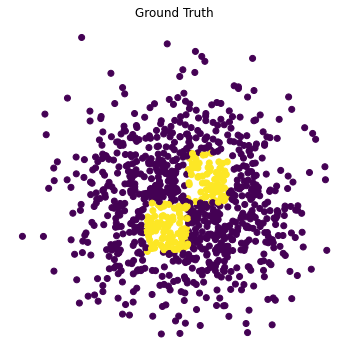

device is : cuda
shape of x is:torch.Size([1000, 64, 64, 64]), shape of labels is: torch.Size([1000, 2])


In [72]:
np.random.seed(1234)

n_samples = 1000
size = 64
output = 2

data = np.random.normal(loc=0, scale=np.sqrt(5), size=(n_samples, size, size, size))
noise = np.random.normal(loc=0, scale=np.sqrt(1), size=(n_samples, size, size, size))
print(f'data shape is: {data.shape}')
W = np.random.normal(loc=0, scale=np.sqrt(5), size=(size,size, size, output))
labeled_data = np.matmul(data.reshape(-1,size*size*size), W.reshape(-1,output))


def to_labels(x,y):
    return (((x>=-2000)&(x<= 0))&((y>=-2500)&(y<=0))) | (((x<=2000)&(x>= 0))&((y<=2500)&(y>=0)))

labels = to_labels(labeled_data[:,0], labeled_data[:,1])



plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = labels)
plt.title('Ground Truth')
plt.axis('off')
plt.show()


device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device is : {device}')
x = data+noise
x = torch.from_numpy(x)
x = x.to(device)
x = x.float()
labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()
print(f'shape of x is:{x.shape}, shape of labels is: {labeled_data.shape}')


# Basic Linear Model

Epoch [1/5], Loss: 6466515.5
Epoch [2/5], Loss: 6384163.5
Epoch [3/5], Loss: 6302357.0
Epoch [4/5], Loss: 6221104.5
Epoch [5/5], Loss: 6140414.0
Done Training


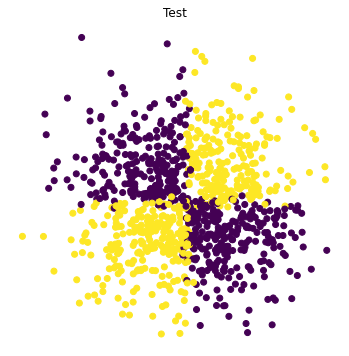

In [73]:
class simple_linear(nn.Module):
    def __init__(self):
        super(simple_linear, self).__init__()
        self.fc = nn.Linear(in_features= 64*64*64, out_features=2)
    def forward(self, x):
        x = x.reshape(-1,64*64*64)
        return self.fc(x)
    
model = simple_linear().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic TRL Model

Epoch [1/5], Loss: 7332061.0
Epoch [2/5], Loss: 7011598.5
Epoch [3/5], Loss: 6706835.0
Epoch [4/5], Loss: 6417262.0
Epoch [5/5], Loss: 6142228.5
Done Training


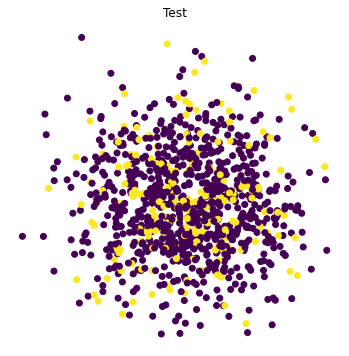

In [75]:
class simple_trl(nn.Module):
    def __init__(self):
        super(simple_trl, self).__init__()
        self.trl = tltorch.TRL(input_shape=(64,64,64), rank=(64,64,64,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(x)
    
model = simple_trl().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic Attached Model

Epoch [1/5], Loss: 6549921.0
Epoch [2/5], Loss: 6521711.5
Epoch [3/5], Loss: 6494307.0
Epoch [4/5], Loss: 6467566.0
Epoch [5/5], Loss: 6441310.5
Done Training


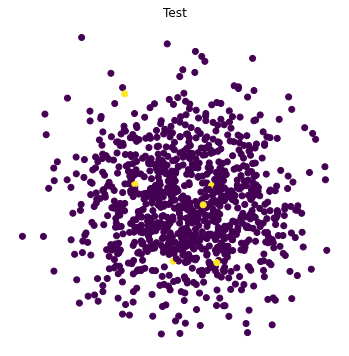

In [78]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=1, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()

# Basic Compressed Model

Epoch [1/5], Loss: 6938117.0
Epoch [2/5], Loss: 6864162.5
Epoch [3/5], Loss: 6792626.5
Epoch [4/5], Loss: 6723414.0
Epoch [5/5], Loss: 6656418.0
Done Training


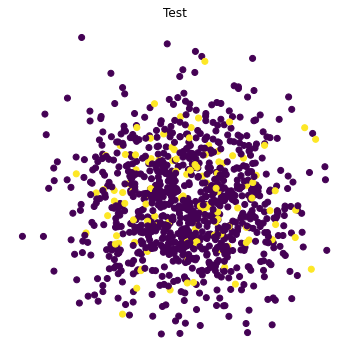

In [79]:
class simple_attached(nn.Module):
    def __init__(self):
        super(simple_attached, self).__init__()
        self.reshape = reshape(split=[2,2,2], map_type=2, device=device)
        self.trl = tltorch.TRL(input_shape=(2,2,2,32,32,32), rank=(2,2,2,32,32,32,2), output_shape=(2), bias=True, factorization='tucker')
    def forward(self, x):
        return self.trl(self.reshape(x))
    
model = simple_attached().to(device)

# Train for 5 epochs
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

n_epochs = 5


for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, labeled_data)

    loss.backward()
    optimizer.step()
    
    print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item()}')

print(f'Done Training')
model.eval()
outputs = model(x)

# Plot the results
outputs = outputs.detach().cpu().numpy()
predict = to_labels(outputs[:,0], outputs[:,1])
labeled_data = labeled_data.detach().cpu().numpy()

plt.figure(figsize=(6, 6))
plt.scatter(labeled_data[:, 0], labeled_data[:, 1], c = predict)
plt.title('Test')
plt.axis('off')
plt.show()

labeled_data = torch.from_numpy(labeled_data)
labeled_data = labeled_data.to(device)
labeled_data = labeled_data.float()